<a href="https://colab.research.google.com/github/honestfarmer-cod/greends-pml/blob/main/PML_Assig01_David.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/honestfarmer-cod/greends-pml/blob/main/notebook.ipynb)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf


In [2]:
data = pd.read_csv("winequality-white.csv", sep=";")
data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
X = data.drop("quality", axis=1)  # inputs
y = data["quality"]              # output
X.shape, y.shape


((4898, 11), (4898,))

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)  # output: predicted quality (continuous)
])

In [7]:

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


In [8]:

EPOCHS = 100
BATCH_SIZE = 32  # BATCH: number of examples seen before weight update

history = model.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=0
)


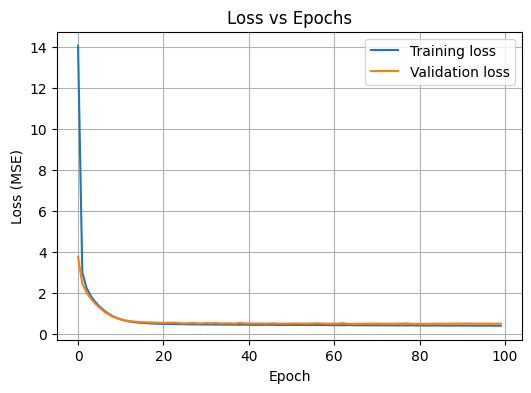

In [9]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
y_pred = model.predict(X_test_scaled).flatten()


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [11]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Test MSE:", mse)
print("Test R^2:", r2)


Test MSE: 0.533878743648529
Test R^2: 0.31065547466278076


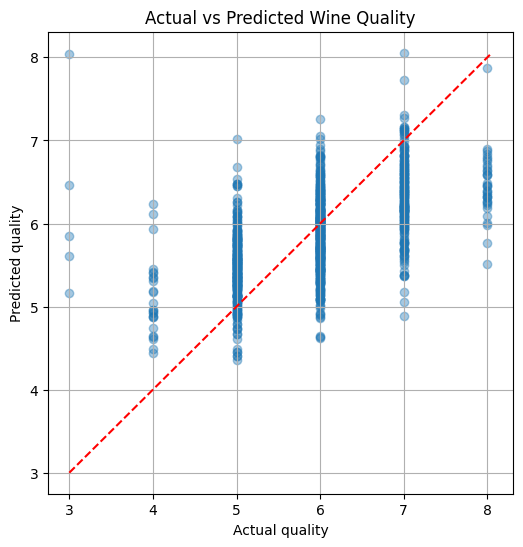

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual quality')
plt.ylabel('Predicted quality')
plt.title('Actual vs Predicted Wine Quality')
# reference line y = x
min_q = min(y_test.min(), y_pred.min())
max_q = max(y_test.max(), y_pred.max())
plt.plot([min_q, max_q], [min_q, max_q], 'r--')
plt.grid(True)
plt.show()
